In [1]:
import pandas as pd
from pathlib import Path

# EXTRACT
csv_path = Path("../data/candidates.csv")

df_raw = pd.read_csv(csv_path, delimiter=",")

print("Archivo cargado correctamente.")
print(f"Filas y columnas: {df_raw.shape}")

display(df_raw.head())

print("\nNombres de columnas:")
print(df_raw.columns.tolist())

print("\nValores nulos por columna:")
display(df_raw.isnull().sum())

Archivo cargado correctamente.
Filas y columnas: (50000, 10)


,First Name,Last Name,Email,Country,Application Date,Yoe,Seniority,Technology,Code Challenge Score,Technical Interview
0,Danielle,Levy,ashleysellers@gmail.com,UK,2024-11-23,6.0,Manager,Mulesoft,0,0.0
1,Angel,Ortega,gary31@yahoo.com,USA,2025-03-21,19.0,NaN,Mulesoft,9,6.0
2,Joshua,Lopez,austingarcia@hotmail.com,Ecuador,2024-10-12,14.0,NaN,Mulesoft,2,5.0
3,Jeffrey,Powers,courtney32@gmail.com,Colombia,2024-10-29,10.0,Lead,Java Backend,3,NaN
4,Jill,Robinson,stokessuzanne@gmail.com,Australia,2022-04-05,7.0,Junior,QA Manual,3,3.0



Nombres de columnas:
['First Name', 'Last Name', 'Email', 'Country', 'Application Date', 'Yoe', 'Seniority', 'Technology', 'Code Challenge Score', 'Technical Interview']

Valores nulos por columna:


First Name                 0
Last Name                  0
Email                   2509
Country                    0
Application Date           0
Yoe                     2491
Seniority               2511
Technology                 0
Code Challenge Score       0
Technical Interview     2506
dtype: int64

In [2]:
# TRANSFORM 1: limpieza y normalización

# Trabajamos sobre una copia, sin modificar el CSV original
df_clean = df_raw.copy()

# Estandarizar nombres de columnas
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Ajustar este nombre al que usaremos en el Warehouse
df_clean = df_clean.rename(
    columns={"technical_interview": "technical_interview_score"}
)

# Convertir fecha y campos numéricos
df_clean["application_date"] = pd.to_datetime(
    df_clean["application_date"],
    errors="coerce"
)

for column in ["yoe", "code_challenge_score", "technical_interview_score"]:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

# Limpiar columnas de texto
text_columns = [
    "first_name", "last_name", "email",
    "country", "technology", "seniority"
]

for column in text_columns:
    df_clean[column] = df_clean[column].astype("string").str.strip()

# Estandarizar país y seniority
df_clean["country"] = df_clean["country"].str.title()
df_clean["country"] = df_clean["country"].replace({
    "Usa": "USA",
    "United States": "USA",
    "United States Of America": "USA"
})

df_clean["seniority"] = df_clean["seniority"].str.title()

# Eliminar duplicados exactos y registros con datos esenciales faltantes
initial_rows = len(df_clean)

df_clean = df_clean.drop_duplicates()

required_columns = [
    "first_name", "last_name", "email", "country",
    "application_date", "yoe", "seniority", "technology",
    "code_challenge_score", "technical_interview_score"
]

df_clean = df_clean.dropna(subset=required_columns)

# Mantener rangos válidos
df_clean = df_clean[
    df_clean["yoe"].between(0, 50)
    & df_clean["code_challenge_score"].between(0, 10)
    & df_clean["technical_interview_score"].between(0, 10)
].copy()

print(f"Registros originales: {initial_rows}")
print(f"Registros válidos después de limpieza: {len(df_clean)}")
print(f"Registros eliminados: {initial_rows - len(df_clean)}")

display(df_clean.head())

Registros originales: 50000
Registros válidos después de limpieza: 39048
Registros eliminados: 10952


,first_name,last_name,email,country,application_date,yoe,seniority,technology,code_challenge_score,technical_interview_score
0,Danielle,Levy,ashleysellers@gmail.com,Uk,2024-11-23,6.0,Manager,Mulesoft,0,0.0
4,Jill,Robinson,stokessuzanne@gmail.com,Australia,2022-04-05,7.0,Junior,QA Manual,3,3.0
5,Erica,Vance,millerrachel@yahoo.com,Uk,2024-12-27,20.0,Manager,Social Media Community Management,2,3.0
7,Christopher,Baird,nicholasbautista@yahoo.com,Brazil,2024-01-20,18.0,Manager,React Frontend,6,6.0
8,Robert,Lee,natalie15@gmail.com,Germany,2024-03-29,10.0,Junior,QA Manual,7,3.0


In [3]:
# TRANSFORM 2: regla de negocio HIRED

df_clean["is_hired"] = (
    (df_clean["code_challenge_score"] >= 7)
    & (df_clean["technical_interview_score"] >= 7)
).astype(int)

print("Regla HIRED aplicada.")
print(f"Total de candidatos contratados: {df_clean['is_hired'].sum()}")

display(
    df_clean[
        [
            "code_challenge_score",
            "technical_interview_score",
            "is_hired"
        ]
    ].head(10)
)

Regla HIRED aplicada.
Total de candidatos contratados: 5285


,code_challenge_score,technical_interview_score,is_hired
0,0,0.0,0
4,3,3.0,0
5,2,3.0,0
7,6,6.0,0
8,7,3.0,0
9,9,9.0,1
10,3,5.0,0
12,10,7.0,1
13,7,3.0,0
14,7,2.0,0


In [4]:
# LOAD 1: crear el Data Warehouse y sus tablas

import sqlite3
from pathlib import Path

# Crear carpeta y archivo de base SQLite
Path("../warehouse").mkdir(exist_ok=True)

connection = sqlite3.connect("../warehouse/candidates_dw.db")
connection.execute("PRAGMA foreign_keys = ON")

# Ejecutar el script que crea las dimensiones y la tabla de hechos
with open("../sql/create_star_schema.sql", "r", encoding="utf-8") as file:
    connection.executescript(file.read())

connection.commit()

# Confirmar las tablas creadas
tables = connection.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
""").fetchall()

print("Warehouse y tablas creados:")
for table in tables:
    print("-", table[0])

Warehouse y tablas creados:
- dim_candidates
- dim_date
- dim_job_profiles
- dim_location
- fact_applications
- sqlite_sequence


In [5]:
# LOAD 2: cargar tablas de dimensiones

# Vaciar las tablas si se vuelve a ejecutar el notebook
connection.execute("DELETE FROM fact_applications")
connection.execute("DELETE FROM dim_candidates")
connection.execute("DELETE FROM dim_date")
connection.execute("DELETE FROM dim_location")
connection.execute("DELETE FROM dim_job_profiles")

# Dimensión candidatos
dim_candidates = (
    df_clean[["first_name", "last_name", "email"]]
    .drop_duplicates(subset="email")
)
dim_candidates.to_sql(
    "dim_candidates",
    connection,
    if_exists="append",
    index=False
)

# Dimensión ubicación / país
dim_location = (
    df_clean[["country"]]
    .drop_duplicates()
    .rename(columns={"country": "country_name"})
)
dim_location.to_sql(
    "dim_location",
    connection,
    if_exists="append",
    index=False
)

# Dimensión perfil laboral
dim_job_profiles = (
    df_clean[["technology", "seniority"]]
    .drop_duplicates()
)
dim_job_profiles.to_sql(
    "dim_job_profiles",
    connection,
    if_exists="append",
    index=False
)

# Dimensión fecha
dim_date = pd.DataFrame({
    "date_id": df_clean["application_date"].dt.strftime("%Y%m%d").astype(int),
    "full_date": df_clean["application_date"].dt.strftime("%Y-%m-%d"),
    "year": df_clean["application_date"].dt.year,
    "month": df_clean["application_date"].dt.month,
    "day": df_clean["application_date"].dt.day
}).drop_duplicates(subset="date_id")

dim_date.to_sql(
    "dim_date",
    connection,
    if_exists="append",
    index=False
)

connection.commit()

# Comprobar carga
for table in [
    "dim_candidates",
    "dim_location",
    "dim_job_profiles",
    "dim_date"
]:
    count = connection.execute(
        f"SELECT COUNT(*) FROM {table}"
    ).fetchone()[0]
    print(f"{table}: {count} registros")

dim_candidates: 36301 registros
dim_location: 13 registros
dim_job_profiles: 84 registros
dim_date: 1827 registros


In [6]:
# LOAD 3: construir y cargar la tabla de hechos

# Leer identificadores generados en las dimensiones
candidate_keys = pd.read_sql(
    "SELECT candidate_id, email FROM dim_candidates",
    connection
)

country_keys = pd.read_sql(
    "SELECT country_id, country_name FROM dim_location",
    connection
)

profile_keys = pd.read_sql(
    """
    SELECT job_profile_id, technology, seniority
    FROM dim_job_profiles
    """,
    connection
)

# Relacionar cada registro limpio con las claves de sus dimensiones
fact_data = df_clean.merge(
    candidate_keys,
    on="email",
    how="left"
).merge(
    country_keys,
    left_on="country",
    right_on="country_name",
    how="left"
).merge(
    profile_keys,
    on=["technology", "seniority"],
    how="left"
)

# Crear la tabla de hechos con métricas y claves foráneas
fact_applications = pd.DataFrame({
    "job_profile_id": fact_data["job_profile_id"],
    "candidate_id": fact_data["candidate_id"],
    "country_id": fact_data["country_id"],
    "date_id": fact_data["application_date"].dt.strftime("%Y%m%d").astype(int),
    "yoe": fact_data["yoe"],
    "code_challenge_score": fact_data["code_challenge_score"],
    "technical_interview_score": fact_data["technical_interview_score"],
    "is_hired": fact_data["is_hired"]
})

# Insertar los registros en el Data Warehouse
fact_applications.to_sql(
    "fact_applications",
    connection,
    if_exists="append",
    index=False
)

connection.commit()

# Verificación final de la carga
total_applications = connection.execute(
    "SELECT COUNT(*) FROM fact_applications"
).fetchone()[0]

total_hired = connection.execute(
    "SELECT SUM(is_hired) FROM fact_applications"
).fetchone()[0]

print(f"Aplicaciones cargadas: {total_applications}")
print(f"Candidatos contratados: {total_hired}")

Aplicaciones cargadas: 39048
Candidatos contratados: 5285


In [7]:
# KPI: consultas ejecutadas exclusivamente desde el Data Warehouse

query_hires_technology = """
SELECT jp.technology, COUNT(*) AS hires
FROM fact_applications f
JOIN dim_job_profiles jp ON f.job_profile_id = jp.job_profile_id
WHERE f.is_hired = 1
GROUP BY jp.technology
ORDER BY hires DESC;
"""

kpi_technology = pd.read_sql_query(query_hires_technology, connection)

display(kpi_technology)

,technology,hires
0,React Frontend,467
1,Client Success,466
2,Sales,459
3,Development - CMS Backend,457
4,Python Developer,445
5,DevOps,445
6,Social Media Community Management,443
7,Adobe Experience Manager,441
8,QA Manual,425
9,Java Backend,417


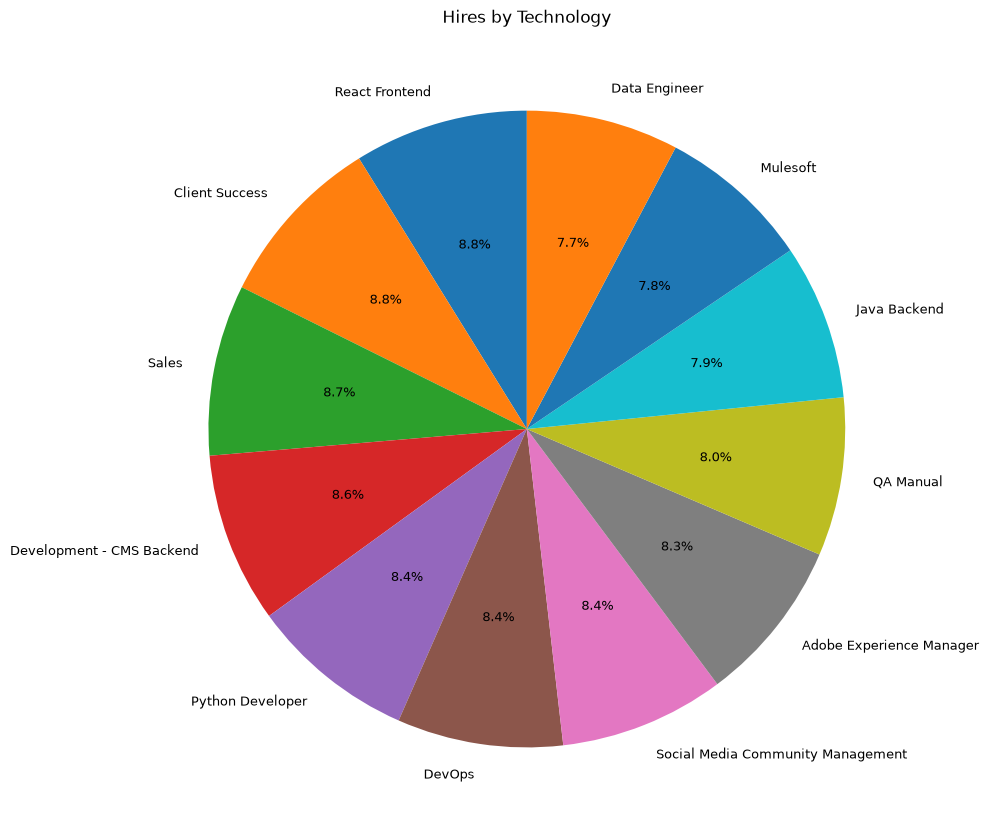

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización 1: contrataciones por tecnología
plt.figure(figsize=(10, 10))

plt.pie(
    kpi_technology["hires"],
    labels=kpi_technology["technology"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 9}
)

plt.title("Hires by Technology")
plt.tight_layout()
plt.show()

In [9]:
# KPI 2: contrataciones por año, consultadas desde SQLite

query_hires_year = """
SELECT
    d.year,
    COUNT(*) AS hires
FROM fact_applications f
JOIN dim_date d
    ON f.date_id = d.date_id
WHERE f.is_hired = 1
GROUP BY d.year
ORDER BY d.year;
"""

kpi_year = pd.read_sql_query(query_hires_year, connection)

display(kpi_year)

,year,hires
0,2021,890
1,2022,1065
2,2023,1077
3,2024,1049
4,2025,1065
5,2026,139


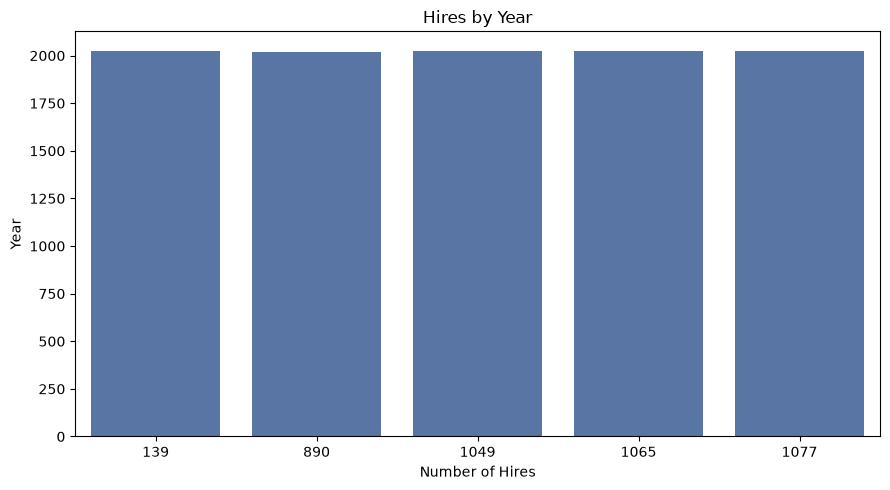

In [10]:
# Visualización 2: contrataciones por año

plt.figure(figsize=(9, 5))

sns.barplot(
    data=kpi_year,
    x="hires",
    y="year",
    color="#4C72B0"
)

plt.title("Hires by Year")
plt.xlabel("Number of Hires")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

In [11]:
# KPI 3: contrataciones por seniority, consultadas desde SQLite

query_hires_seniority = """
SELECT
    jp.seniority,
    COUNT(*) AS hires
FROM fact_applications f
JOIN dim_job_profiles jp
    ON f.job_profile_id = jp.job_profile_id
WHERE f.is_hired = 1
GROUP BY jp.seniority
ORDER BY hires DESC;
"""

kpi_seniority = pd.read_sql_query(query_hires_seniority, connection)

display(kpi_seniority)

,seniority,hires
0,Intern,797
1,Senior,784
2,Mid-Level,782
3,Manager,736
4,Junior,735
5,Lead,728
6,Trainee,723


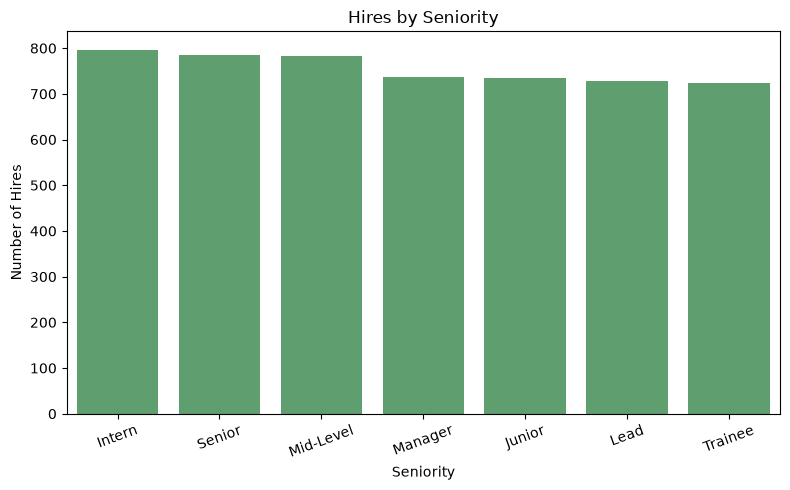

In [12]:
# Visualización 3: contrataciones por seniority

plt.figure(figsize=(8, 5))

sns.barplot(
    data=kpi_seniority,
    x="seniority",
    y="hires",
    color="#55A868"
)

plt.title("Hires by Seniority")
plt.xlabel("Seniority")
plt.ylabel("Number of Hires")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [13]:
# KPI 4: contrataciones por país y año, consultadas desde SQLite

query_hires_country_year = """
SELECT
    d.year,
    l.country_name,
    COUNT(*) AS hires
FROM fact_applications f
JOIN dim_date d
    ON f.date_id = d.date_id
JOIN dim_location l
    ON f.country_id = l.country_id
WHERE f.is_hired = 1
  AND l.country_name IN ('USA', 'Brazil', 'Colombia', 'Ecuador')
GROUP BY d.year, l.country_name
ORDER BY d.year, l.country_name;
"""

kpi_country_year = pd.read_sql_query(
    query_hires_country_year,
    connection
)

display(kpi_country_year)

,year,country_name,hires
0,2021,Brazil,76
1,2021,Colombia,70
2,2021,Ecuador,56
3,2021,USA,71
4,2022,Brazil,75
5,2022,Colombia,70
6,2022,Ecuador,91
7,2022,USA,71
8,2023,Brazil,75
9,2023,Colombia,92


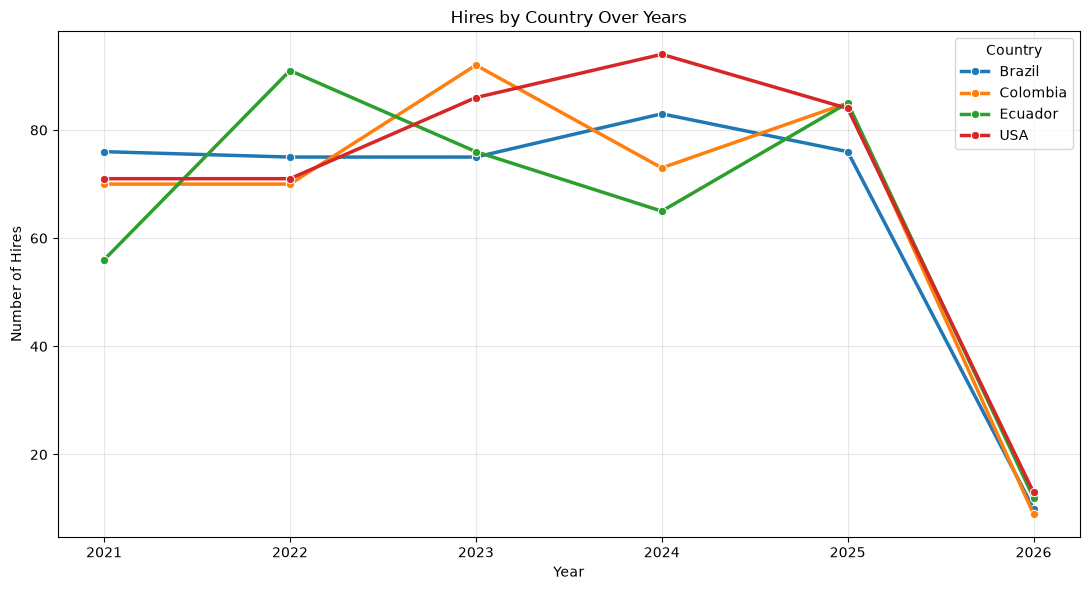

In [14]:
# Visualización 4: contrataciones por país a lo largo de los años

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=kpi_country_year,
    x="year",
    y="hires",
    hue="country_name",
    marker="o",
    linewidth=2.5
)

plt.title("Hires by Country Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Hires")
plt.legend(title="Country")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()